# `LeaveClusterOut`

`LeaveClusterOut` implements spatial block cross-validation using a
user-supplied clustering estimator. Each fold holds out one spatial cluster
as the test set; the training set is all observations in every other cluster.

This is the leave-one-block-out analogue of `ClusterStratifiedKFold`. Unlike
DGGS-based blocking, the cluster shapes adapt to the spatial density of the
data. HDBSCAN also produces *noise points* (label = -1) — observations too
isolated to belong to any cluster — and `LeaveClusterOut` offers three ways to
handle them:

- **`train_only`** (default): noise points appear in every training set, never test.
- **`drop`**: noise points are excluded from both train and test.
- **`nearest`**: each noise point is reassigned to the cluster of its nearest
  non-noise neighbour and then participates in that cluster's fold as a regular member.

In [1]:
import colormaps
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.cluster import HDBSCAN

from spml.validation import LeaveClusterOut

/Users/ljwolf/miniforge3/envs/analysis/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
DATA_PATH = '/Users/ljwolf/Dropbox/work/projects/spquadtree/code/kc_house_data.csv'

df = pd.read_csv(DATA_PATH)
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df['long'], df['lat']),
    crs='EPSG:4326',
)
print(str(len(gdf)) + ' house sales')

21613 house sales


## Fit HDBSCAN

Using `metric='haversine'` lets HDBSCAN work directly in geographic space
without reprojecting. Haversine expects coordinates as `(lat, lon)` in radians.

We pre-fit the clusterer and pass it to `LeaveClusterOut`. When `labels_` is
already present on the estimator, `split()` uses those labels directly and
does not refit — useful for comparing `noise` options without redundant work.

The scan below finds the largest `min_cluster_size` that still yields at
least 8 clusters.

In [3]:
# haversine expects (lat, lon) in radians
coords_rad = np.radians(np.column_stack([gdf.geometry.y, gdf.geometry.x]))

best_mcs = 100
for mcs in [100, 150, 200, 250, 300, 400, 500]:
    labels_ = HDBSCAN(min_cluster_size=mcs, metric='haversine').fit(coords_rad).labels_
    n = (np.unique(labels_) >= 0).sum()
    n_noise = (labels_ == -1).sum()
    print('  min_cluster_size=' + str(mcs) + ' -> ' + str(n) + ' clusters, '
          + str(n_noise) + ' noise (' + str(round(100 * n_noise / len(labels_), 1)) + '%)')
    if n >= 8:
        best_mcs = mcs

print('\nUsing min_cluster_size=' + str(best_mcs))
hdb = HDBSCAN(min_cluster_size=best_mcs, metric='haversine').fit(coords_rad)

/Users/ljwolf/miniforge3/envs/analysis/lib/python3.14/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


  min_cluster_size=100 -> 5 clusters, 1018 noise (4.7%)


/Users/ljwolf/miniforge3/envs/analysis/lib/python3.14/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


  min_cluster_size=150 -> 3 clusters, 1128 noise (5.2%)


/Users/ljwolf/miniforge3/envs/analysis/lib/python3.14/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


...

/Users/ljwolf/miniforge3/envs/analysis/lib/python3.14/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


  min_cluster_size=400 -> 6 clusters, 11581 noise (53.6%)


/Users/ljwolf/miniforge3/envs/analysis/lib/python3.14/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


  min_cluster_size=500 -> 3 clusters, 6594 noise (30.5%)

Using min_cluster_size=300


/Users/ljwolf/miniforge3/envs/analysis/lib/python3.14/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


## Cluster assignments

In [4]:
# Pass the pre-fitted HDBSCAN; LeaveClusterOut detects labels_ and skips refitting
lco = LeaveClusterOut(hdb, noise='train_only')
splits_to = list(lco.split(gdf))

labels = lco.labels_
n_noise = (labels == -1).sum()
print('Clusters (folds) : ' + str(lco.n_clusters_))
print('Noise points     : ' + str(n_noise) + ' (' + str(round(100 * n_noise / len(gdf), 1)) + '%)')

Clusters (folds) : 8
Noise points     : 11557 (53.5%)


/Users/ljwolf/Dropbox/work/dev/geovalidate/src/geovalidate/cv/_utils.py:58: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  c = X.geometry.centroid


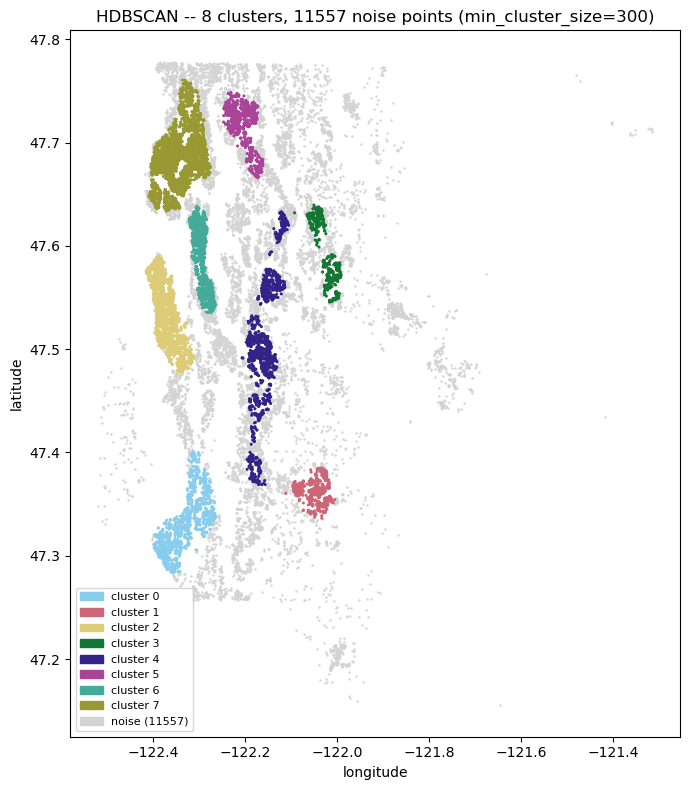

In [5]:
fig, ax = plt.subplots(figsize=(7, 8))
noise_mask = labels == -1

ax.scatter(
    gdf.geometry.x[noise_mask], gdf.geometry.y[noise_mask],
    color='lightgrey', s=0.5, zorder=1,
)
cluster_labels = labels[~noise_mask]
sc = ax.scatter(
    gdf.geometry.x[~noise_mask], gdf.geometry.y[~noise_mask],
    c=cluster_labels, cmap=colormaps.safe[:lco.n_clusters_], s=1.5, zorder=2,
    vmin=0, vmax=lco.n_clusters_ - 1,
)
handles = [
    mpatches.Patch(color=sc.cmap(sc.norm(i)), label='cluster ' + str(i))
    for i in range(lco.n_clusters_)
]
handles.append(mpatches.Patch(color='lightgrey', label='noise (' + str(n_noise) + ')'))
ax.legend(handles=handles, loc='lower left', fontsize=8)
ax.set_title(
    'HDBSCAN -- ' + str(lco.n_clusters_) + ' clusters, '
    + str(n_noise) + ' noise points (min_cluster_size=' + str(best_mcs) + ')'
)
ax.set_xlabel('longitude')
ax.set_ylabel('latitude')
plt.tight_layout()
plt.show()

## Noise point options: `train_only`, `drop`, and `nearest`

Noise points are never the sole subject of a test fold. The `noise` parameter
controls how they participate in each fold:

- **`train_only`** (default): noise points are in every training set.
  The model sees them during training but is never evaluated on them.
- **`drop`**: noise points are excluded from both train and test.
  Use this when nearby noise points might leak spatial information
  about the held-out cluster.
- **`nearest`**: each noise point is reassigned to the cluster of its
  nearest non-noise neighbour. It then acts as a full member of that cluster —
  appearing in the test fold when that cluster is held out, and in the training
  fold otherwise. The original labels (including `-1`) are preserved in `labels_`.

Because `hdb` is already fitted (has `labels_`), none of the calls below refit.

In [6]:
lco_drop    = LeaveClusterOut(lco.clusterer_, noise='drop')
lco_nearest = LeaveClusterOut(lco.clusterer_, noise='nearest')

splits_drop    = list(lco_drop.split(gdf))
splits_nearest = list(lco_nearest.split(gdf))

stats = []
for i, ((tr_to, te), (tr_dr, _), (tr_nr, _)) in enumerate(
    zip(splits_to, splits_drop, splits_nearest)
):
    stats.append({
        'fold': i,
        'test size': len(te),
        'train (train_only)': len(tr_to),
        'train (drop)': len(tr_dr),
        'train (nearest)': len(tr_nr),
        'noise excluded (drop)': len(tr_to) - len(tr_dr),
    })
pd.DataFrame(stats)

,fold,test size,train (train_only),train (drop),train (nearest),noise excluded (drop)
0,0,1017,20596,9039,19665,11557
1,1,607,21006,9449,20194,11557
2,2,1687,19926,8369,19349,11557
3,3,472,21141,9584,18708,11557
4,4,1237,20376,8819,17405,11557
5,5,711,20902,9345,19171,11557
6,6,1119,20494,8937,19673,11557
7,7,3206,18407,6850,17126,11557


## Noise handling visualised

The three panels below show the same fold under each noise option.
Orange points on the left are the noise points that `train_only` keeps in training.
In the `nearest` panel, noise points assigned to the held-out cluster appear in the
test set (red) alongside the regular cluster members.

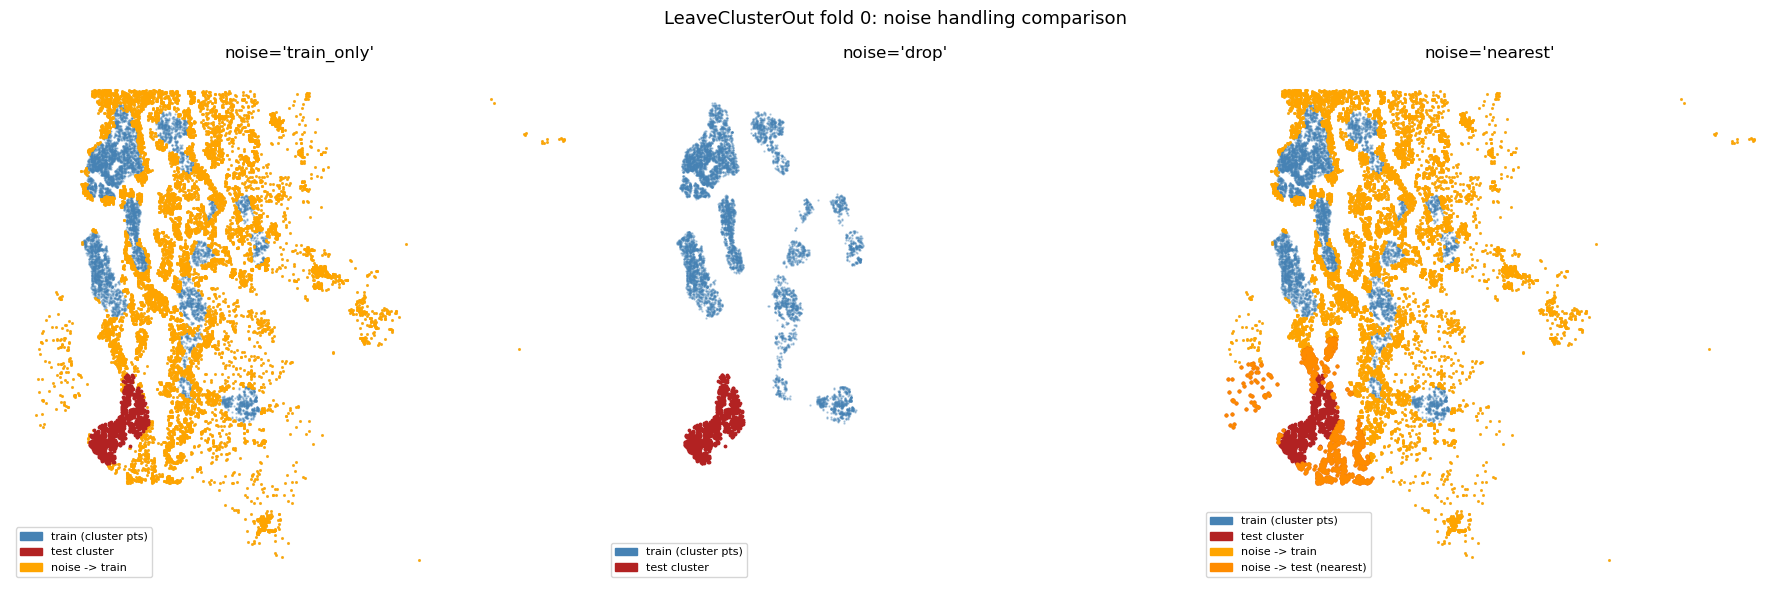

In [7]:
fold = 0
tr_to, te     = splits_to[fold]
tr_dr, _      = splits_drop[fold]
tr_nr, te_nr  = splits_nearest[fold]

noise_in_train   = np.setdiff1d(tr_to, tr_dr)          # noise visible in train_only
noise_in_test_nr = np.intersect1d(te_nr, np.where(lco.labels_ == -1)[0])  # noise -> test in nearest

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=True, sharey=True)

configs = [
    (tr_to, te,    "noise='train_only'"),
    (tr_dr, te,    "noise='drop'"),
    (tr_nr, te_nr, "noise='nearest'"),
]

for ax, (train, test, title) in zip(axes, configs):
    ax.scatter(
        gdf.geometry.x.iloc[train], gdf.geometry.y.iloc[train],
        color='steelblue', s=0.4, alpha=0.4,
    )
    ax.scatter(
        gdf.geometry.x.iloc[test], gdf.geometry.y.iloc[test],
        color='firebrick', s=3, zorder=3,
    )
    ax.set_title(title, fontsize=12)
    ax.set_axis_off()

# highlight noise points on the train_only panel
axes[0].scatter(
    gdf.geometry.x.iloc[noise_in_train], gdf.geometry.y.iloc[noise_in_train],
    color='orange', s=1.5, zorder=2, alpha=0.8,
)

# highlight reassigned noise in the nearest panel (split between test and train)
noise_in_train_nr = np.intersect1d(tr_nr, np.where(lco.labels_ == -1)[0])
axes[2].scatter(
    gdf.geometry.x.iloc[noise_in_test_nr], gdf.geometry.y.iloc[noise_in_test_nr],
    color='darkorange', s=4, zorder=4, alpha=0.9,
)
axes[2].scatter(
    gdf.geometry.x.iloc[noise_in_train_nr], gdf.geometry.y.iloc[noise_in_train_nr],
    color='orange', s=1.5, zorder=2, alpha=0.8,
)

train_patch      = mpatches.Patch(color='steelblue',  label='train (cluster pts)')
test_patch       = mpatches.Patch(color='firebrick',  label='test cluster')
noise_train_patch = mpatches.Patch(color='orange',    label='noise -> train')
noise_test_patch  = mpatches.Patch(color='darkorange', label='noise -> test (nearest)')

axes[0].legend(handles=[train_patch, test_patch, noise_train_patch], loc='lower left', fontsize=8)
axes[1].legend(handles=[train_patch, test_patch], loc='lower left', fontsize=8)
axes[2].legend(handles=[train_patch, test_patch, noise_train_patch, noise_test_patch],
               loc='lower left', fontsize=8)

fig.suptitle('LeaveClusterOut fold ' + str(fold) + ': noise handling comparison', fontsize=13)
plt.tight_layout()
plt.show()